# Fourier Atoms: Continuous and Discrete Sinusoids

The **Fourier basis** decomposes functions into sinusoidal atoms. In both the continuous and discrete settings, these atoms are complex exponentials (or equivalently cosines and sines at integer multiples of a fundamental frequency). Understanding their structure is the foundation of harmonic analysis, signal processing, and numerical methods.

## 1D Fourier atoms

In the continuous periodic setting on $[0, 1]$, the Fourier atoms are
$$
e_k(t) = e^{2\pi i k t}, \quad k \in \mathbb{Z},
$$
which form an orthonormal basis of $L^2([0,1])$. For a signal $f$:
$$
f(t) = \sum_{k=-\infty}^{+\infty} \hat{f}(k)\, e^{2\pi i k t}, \qquad \hat{f}(k) = \int_0^1 f(t) e^{-2\pi i k t}\, dt.
$$

For a **discrete** signal $(f_0, \ldots, f_{n-1})$, the DFT replaces the integral with a sum:
$$
\hat{f}(k) = \sum_{j=0}^{n-1} f_j\, e^{-2\pi i jk/n},
$$
and the atoms become the $n$ sampled sinusoids $e_k(j) = e^{2\pi i jk/n}$.

## 2D Fourier atoms

In two dimensions, the atoms are separable products:
$$
e_{k,\ell}(x, y) = e^{2\pi i(kx + \ell y)},
$$
parameterized by a **frequency vector** $(k, \ell) \in \mathbb{Z}^2$. The 2D atom is a sinusoidal grating oriented perpendicular to $(k, \ell)$ with spatial period $\|(k,\ell)\|^{-1}$.

## Environment

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider

plt.rcParams['figure.dpi'] = 120

## 1D atoms: continuous vs discrete

The continuous atom $\cos(2\pi k t)$ is a smooth sinusoid, while the discrete atom samples it at $n$ equally-spaced points. For $k < n/2$ the sampling is faithful; for $k \geq n/2$ aliasing occurs.

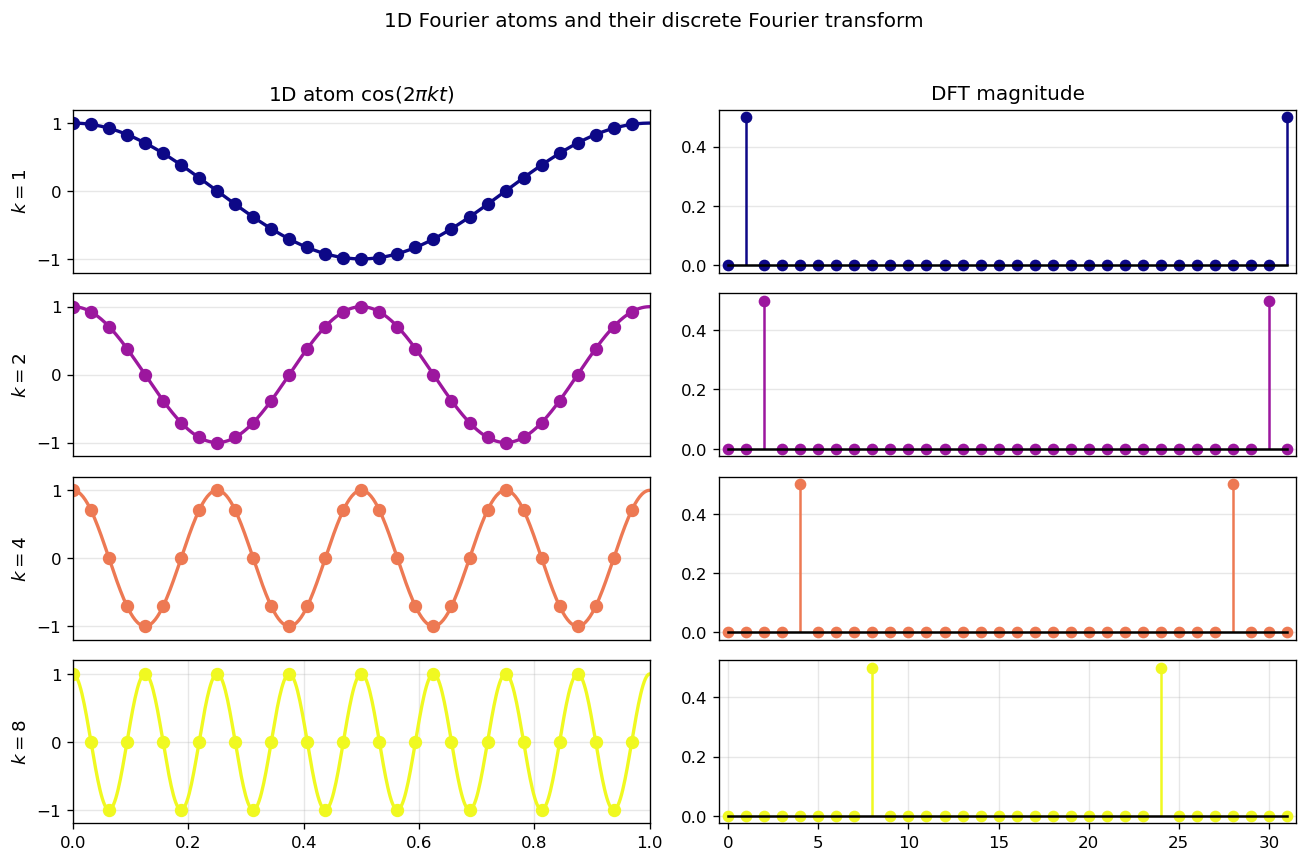

In [2]:
n_disc = 32     # discrete samples
N_cont = 512    # continuous approximation
freqs = [1, 2, 4, 8]

fig, axes = plt.subplots(len(freqs), 2, figsize=(11, 7))
for row, k in enumerate(freqs):
    t = (np.arange(n_disc) / n_disc)
    T = np.linspace(0, 1, N_cont)
    c_cont = np.cos(2 * np.pi * k * T)
    c_disc = np.cos(2 * np.pi * k * t)
    color = plt.cm.plasma(row / (len(freqs)-1))

    axes[row, 0].plot(T, c_cont, '-', lw=2, color=color)
    axes[row, 0].plot(t, c_disc, 'o', ms=7, color=color)
    axes[row, 0].set_xlim(0, 1); axes[row, 0].set_ylim(-1.2, 1.2)
    axes[row, 0].set_ylabel(f'$k={k}$', fontsize=11)
    axes[row, 0].set_title('1D atom $\\cos(2\\pi kt)$' if row==0 else '')
    axes[row, 0].grid(alpha=0.3)
    if row < len(freqs)-1: axes[row, 0].set_xticks([])

    # power spectrum
    F = np.fft.fft(c_disc)
    axes[row, 1].stem(np.arange(n_disc), np.abs(F)/n_disc,
                      linefmt=color, markerfmt='o', basefmt='k-')
    axes[row, 1].set_xlim(-0.5, n_disc-0.5)
    axes[row, 1].set_title('DFT magnitude' if row==0 else '')
    axes[row, 1].grid(alpha=0.3)
    if row < len(freqs)-1: axes[row, 1].set_xticks([])

fig.suptitle('1D Fourier atoms and their discrete Fourier transform', y=1.02)
plt.tight_layout()
plt.show()

## 2D atoms: sinusoidal gratings

Each 2D Fourier atom $\cos(2\pi(k_x x + k_y y)/n)$ is a grating oriented perpendicularly to the frequency vector $(k_x, k_y)$. We display a family of atoms with increasing frequency and varying orientation.

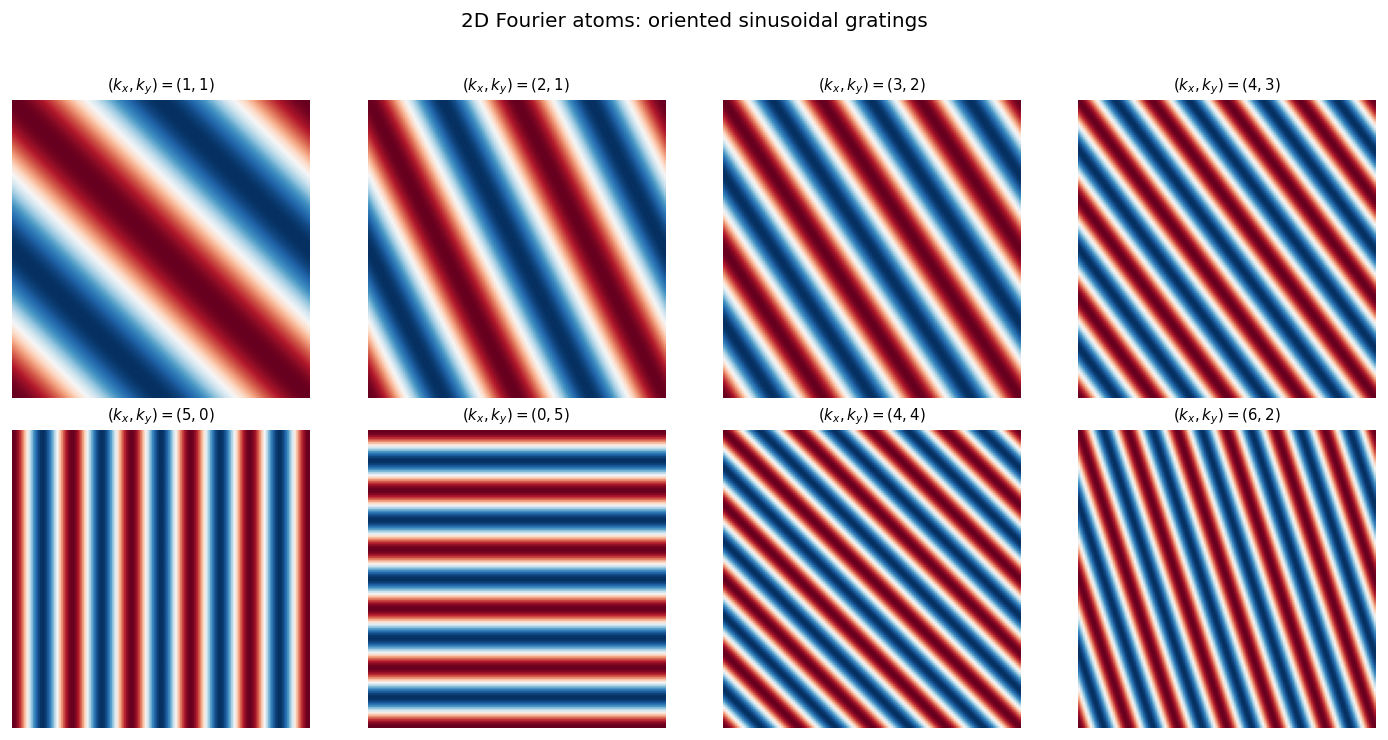

In [3]:
N2 = 128
y2 = np.linspace(0, 1, N2)
X2, Y2 = np.meshgrid(y2, y2)

frequencies_2d = [(1, 1), (2, 1), (3, 2), (4, 3), (5, 0), (0, 5), (4, 4), (6, 2)]
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax, (kx, ky) in zip(axes.ravel(), frequencies_2d):
    atom = np.cos(2 * np.pi * (kx * X2 + ky * Y2))
    ax.imshow(atom, cmap='RdBu_r', vmin=-1, vmax=1, origin='lower')
    ax.set_title(f'$(k_x,k_y)=({kx},{ky})$', fontsize=9)
    ax.axis('off')
fig.suptitle('2D Fourier atoms: oriented sinusoidal gratings', y=1.02)
plt.tight_layout()
plt.show()

## Orthogonality of Fourier atoms

A fundamental property is **orthogonality**: the discrete inner product of atoms at different frequencies is zero. The Gram matrix $G_{k\ell} = \tfrac{1}{n}\langle e_k, e_\ell \rangle$ is the identity, confirming that the DFT is (up to normalization) a unitary transformation.

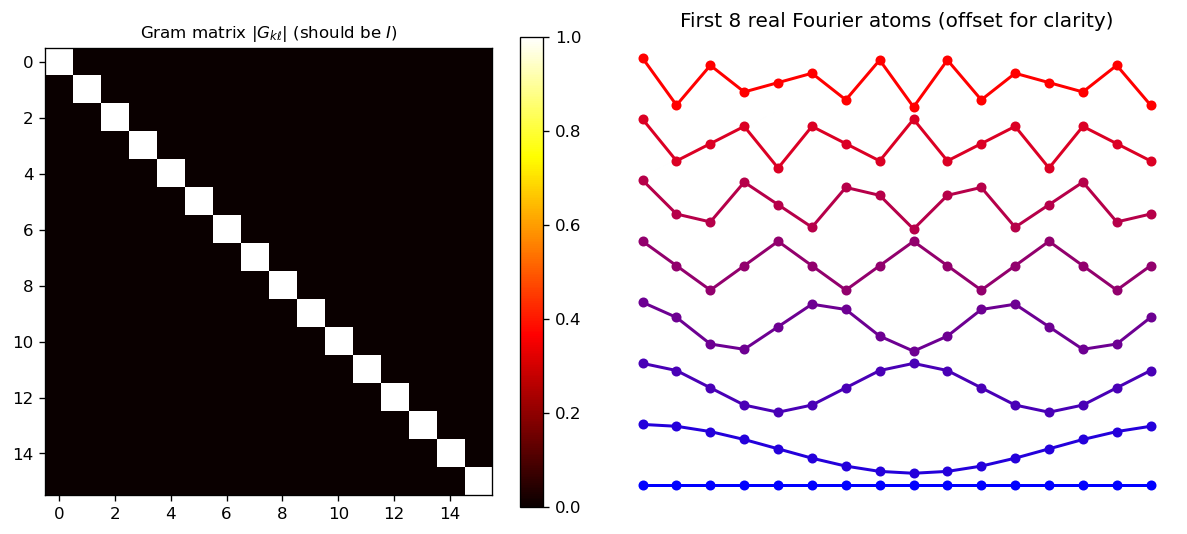

In [4]:
n_orth = 16
t_orth = np.arange(n_orth)
# Build DFT matrix row by row (real part only)
atoms_r = np.array([np.cos(2*np.pi*k*t_orth/n_orth) for k in range(n_orth)])
atoms_i = np.array([np.sin(2*np.pi*k*t_orth/n_orth) for k in range(n_orth)])
atoms_c = np.array([np.exp(2j*np.pi*k*t_orth/n_orth) for k in range(n_orth)])

Gram = (atoms_c @ atoms_c.conj().T).real / n_orth

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
axes[0].imshow(np.abs(Gram), cmap='hot', vmin=0, vmax=1)
axes[0].set_title('Gram matrix $|G_{k\\ell}|$ (should be $I$)', fontsize=10)
plt.colorbar(axes[0].images[0], ax=axes[0])

# Show first 8 real atoms stacked
for k in range(8):
    t_s = (k-0) / 7
    axes[1].plot(t_orth/n_orth, atoms_r[k] + k*2.5, '-o', ms=5,
                 lw=1.8, color=(t_s, 0, 1-t_s), label=f'$k={k}$')
axes[1].set_xlabel('$t$'); axes[1].set_title('First 8 real Fourier atoms (offset for clarity)')
axes[1].axis('off')
plt.tight_layout()
plt.show()

## Interactive: frequency explorer

Adjust the 2D frequency $(k_x, k_y)$ to see the corresponding grating, and observe how the orientation and spatial period change.

In [5]:
def show_atom_2d(kx=2, ky=1):
    atom = np.cos(2 * np.pi * (kx * X2 + ky * Y2))
    period = 1.0 / (np.sqrt(kx**2 + ky**2) + 1e-8)
    angle = np.degrees(np.arctan2(ky, kx)) if kx != 0 or ky != 0 else 0

    fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
    axes[0].imshow(atom, cmap='RdBu_r', vmin=-1, vmax=1, origin='lower')
    axes[0].set_title(fr'$\cos(2\pi({kx}x+{ky}y))$,  period $\approx{period:.2f}$', fontsize=10)
    axes[0].axis('off')

    # 1D slice along x direction
    x1d = np.linspace(0, 1, 500)
    axes[1].plot(x1d, np.cos(2*np.pi*(kx*x1d)), 'b-', lw=2, label=f'$x$-slice ($y=0$)')
    axes[1].plot(x1d, np.cos(2*np.pi*(ky*x1d)), 'r--', lw=2, label=f'$y$-slice ($x=0$)')
    axes[1].set_xlabel('position'); axes[1].set_ylim(-1.2, 1.2)
    axes[1].set_title(f'1D slices,  angle $\\approx{angle:.0f}°$')
    axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)
    plt.tight_layout(); plt.show()

interact(show_atom_2d,
         kx=IntSlider(value=2, min=0, max=10, step=1, description='$k_x$'),
         ky=IntSlider(value=1, min=0, max=10, step=1, description='$k_y$'));

interactive(children=(IntSlider(value=2, description='$k_x$', max=10), IntSlider(value=1, description='$k_y$',…

## Bibliographical resources

- Fourier, J. B. J. (1822). *Théorie analytique de la chaleur*. Firmin Didot.
- Cooley, J. W. and Tukey, J. W. (1965). An algorithm for the machine calculation of complex Fourier series. *Mathematics of Computation*, 19(90), 297–301.
- Stein, E. M. and Weiss, G. (1971). *Introduction to Fourier Analysis on Euclidean Spaces*. Princeton University Press.
- Bracewell, R. N. (2000). *The Fourier Transform and Its Applications* (3rd ed.). McGraw-Hill.
- Mallat, S. (2009). *A Wavelet Tour of Signal Processing: The Sparse Way* (3rd ed.). Academic Press.